## Bayesian Additive Regression Trees (BART) for  Ocean Color Remote Sensing

<img src="./manuscript/figures/eat_my_priors2.png" height="400" alt="BARTimg" style="float: left; margin-right: 30px;">

In this notebook, we build and evaluate a multivariate BART model to predict the logarithm of phytoplankton absorption (aph) at multiple wavelengths using top-of-atmosphere (TOA) radiance measurements. The dataset consists of spectrally-resolved radiance features that have been Fresnel- and Rayleigh-corrected, but not fully atmosphere-corrected, capturing realistic levels of noise and uncertainty in satellite remote sensing.

I leverage the flexibility of BART to accommodate the high multicollinearity among spectral bands without requiring strict assumptions about linearity or parametric form. The model is implemented in PyMC using the pymc-bart extension, allowing for a fully Bayesian treatment of uncertainty and posterior inference.

Key goals of this notebook include:
* Structuring the input data and response variables for multivariate modeling
* Fitting a BART model with a matrix-valued response
* Visualizing posterior draws and posterior predictive distributions
* Diagnosing model behavior
* Laying the groundwork for comparison with alternative models 

This notebook is part of a broader effort to advocate for Bayesian methods in the ocean color community and is ultimately destined for inclusion in a reproducible manuscript. Feedback and discussion are welcome.

Need help with your project? Hit me up: erdemk@pm.me 

In [1]:
from pathlib import Path

import pymc as pm
import pymc_bart as pmb

import pandas as pd
import numpy as np
import matplotlib.pyplot as pp
from matplotlib.lines import Line2D
import arviz as az
import seaborn as sb

In [2]:
print('Package Versions: ', end='\n' + 50*'--' + '\n')
print(f'PyMC - {pm.__version__}')
print(f'PyMC-BART - {pmb.__version__}')
print(f'PanDaS - {pd.__version__}')
print(f'Arviz - {az.__version__}')
print(f'Seaborn - {sb.__version__}')

Package Versions: 
----------------------------------------------------------------------------------------------------
PyMC - 5.20.1
PyMC-BART - 0.9.0
PanDaS - 2.2.3
Arviz - 0.21.0
Seaborn - 0.13.2


In [3]:
pp.style.use('arviz-darkgrid')

#### Phytoplankton Absorption Prediction


In [4]:
data_dir = Path.cwd() / 'data' / '03_transformed'
data_dir.exists()

True

In [5]:
df_log = pd.read_parquet(data_dir / 'df_log.pqt')

In [6]:
aph_subset = df_log.filter(regex='Rrc|aph')

In [7]:
aph_subset.head()

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_aph443,log_aph555,log_aph670
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN


In [8]:
image_save_path = Path.cwd() / 'manuscript' /'figures'
assert image_save_path.exists()

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


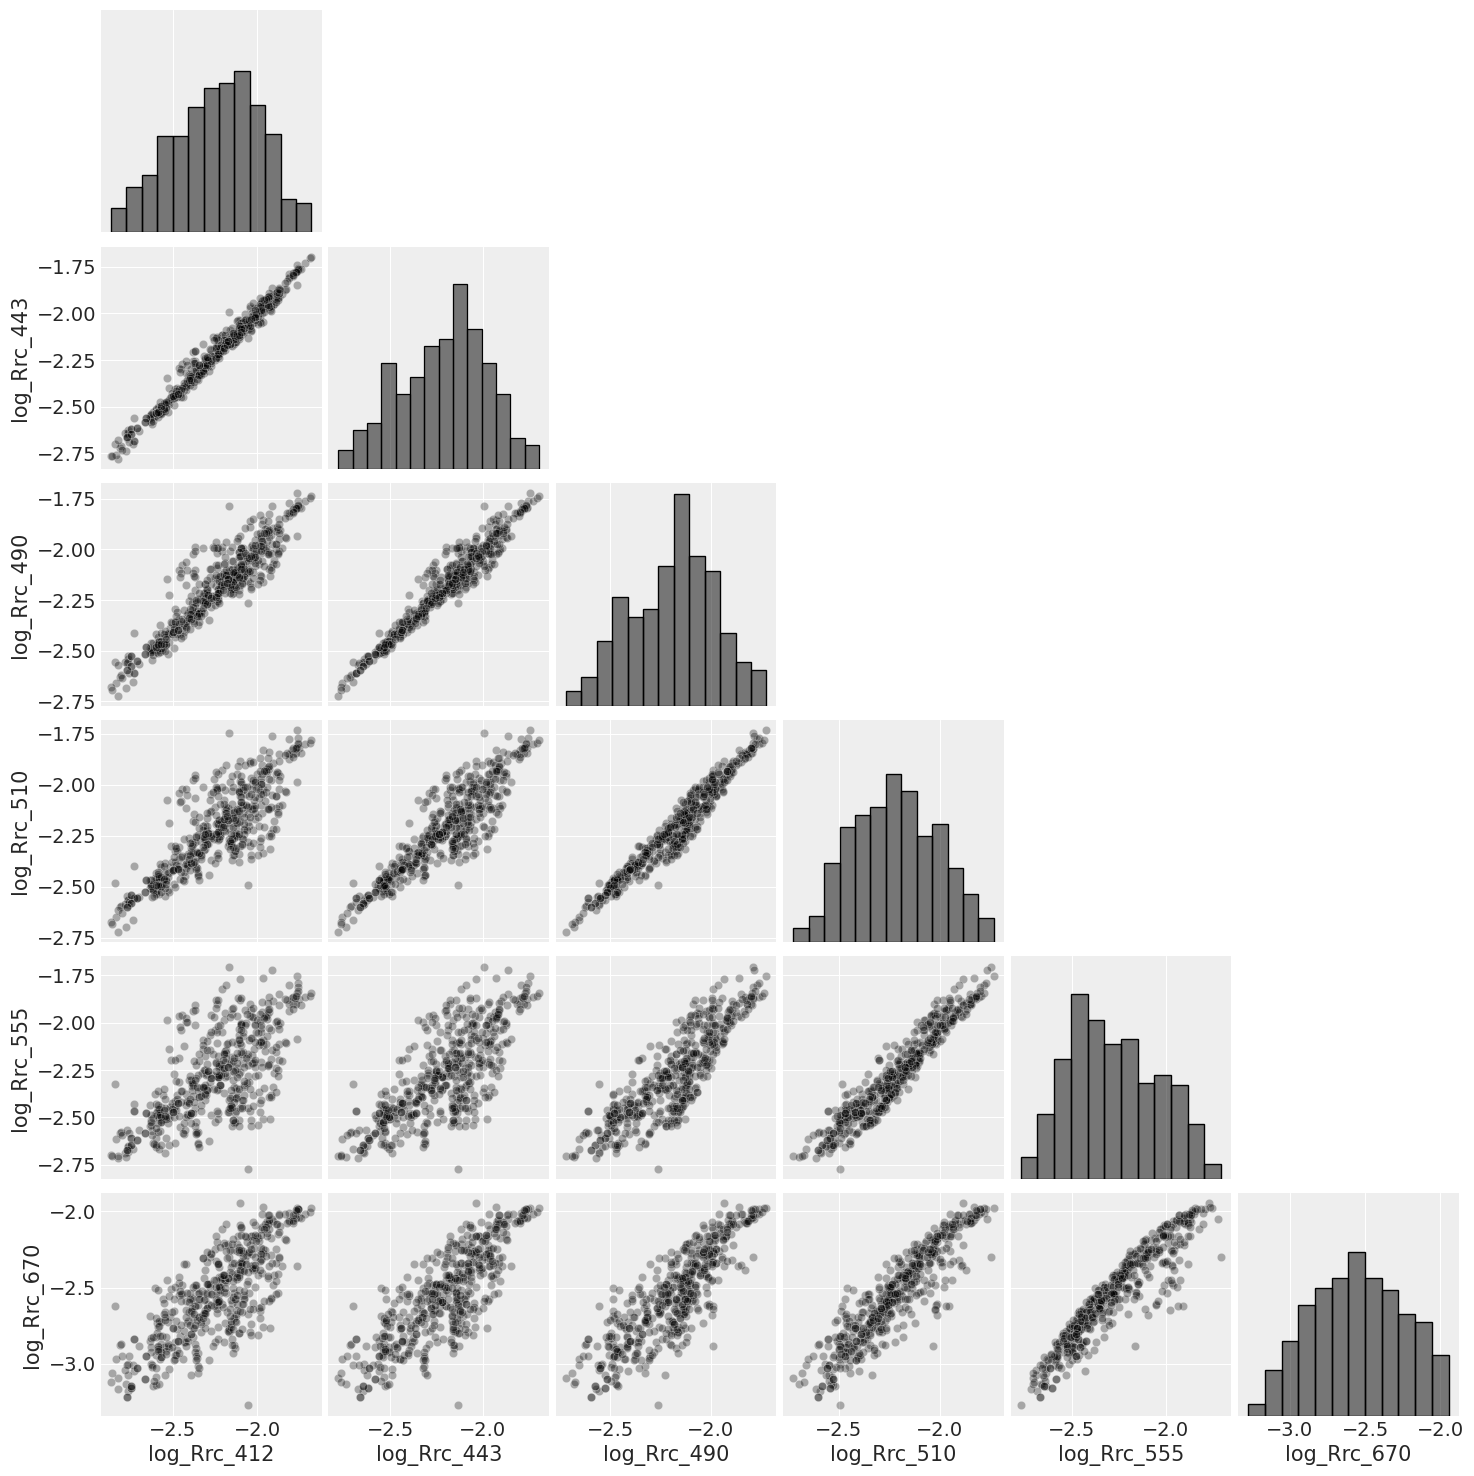

In [9]:
sb.pairplot(aph_subset.filter(
    like='Rrc', axis=1), corner=True, plot_kws = {'color': 'k', 'alpha': 0.3}, 
    diag_kws={'color': 'k', 'alpha': 0.5})
f = pp.gcf()
f.savefig(image_save_path / 'log_rrc_pairplot.png', dpi=300)
f.savefig(image_save_path / 'log_rrc_pairplot.pdf', dpi=300)

In [10]:
aph_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_Rrc_412  494 non-null    float64
 1   log_Rrc_443  494 non-null    float64
 2   log_Rrc_490  494 non-null    float64
 3   log_Rrc_510  494 non-null    float64
 4   log_Rrc_555  494 non-null    float64
 5   log_Rrc_670  494 non-null    float64
 6   log_aph443   168 non-null    float64
 7   log_aph555   165 non-null    float64
 8   log_aph670   168 non-null    float64
dtypes: float64(9)
memory usage: 35.0 KB


In [11]:
X = aph_subset.dropna().filter(regex='Rrc')
Y = aph_subset.dropna().filter(regex='aph')
y = aph_subset.dropna().log_aph443

<Axes: ylabel='Count'>

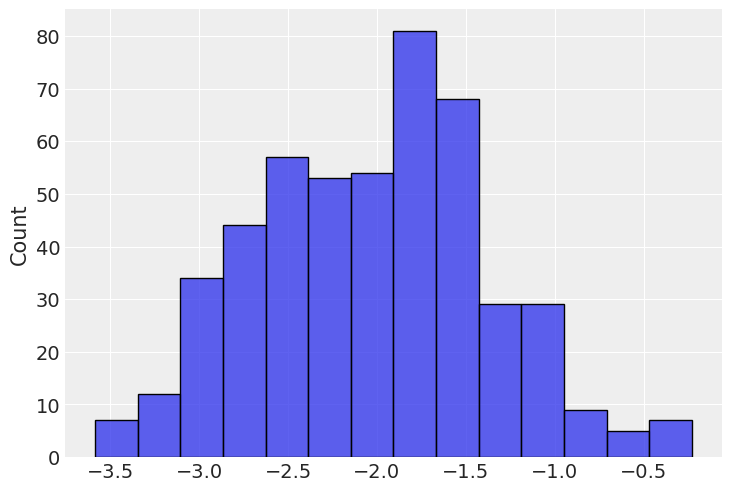

In [12]:
sb.histplot(Y.values.flatten())

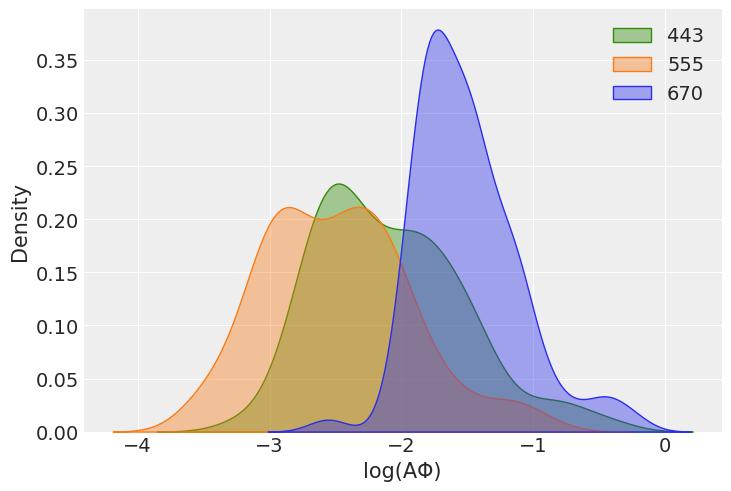

In [13]:
ax = sb.kdeplot(aph_subset.dropna().filter(regex='aph'), fill=True, alpha=0.4, legend=False)
ax.legend(['443', '555', '670'])
ax.set_xlabel('log(AΦ)')
f = pp.gcf()
f.savefig(image_save_path / 'aph_dist.png', dpi=300)
f.savefig(image_save_path / 'aph_dist.pdf', dpi=300)

## Modeling

### Modeling Preparation

In [14]:
x_idx, x_names = X.columns.factorize()
y_idx, y_names = Y.columns.factorize()
λ =   [li.split('Rrc_')[-1] for li in x_names]
λ_aph =   [li.split('aph')[-1] for li in y_names]
coords= {
    'obs_idx': X.index,
    'λ_toa': λ, 
    'λ_aφ' : λ_aph
}

### Aφ Model 1 - BART

This is a first stab at predicting Phytoplankton absorption at all 3 wavelengths

In [31]:
with pm.Model(coords=coords) as m_aph:
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    σ = pm.HalfNormal('σ', 0.5, dims='λ_aφ')
    μ = pmb.BART('μ', X=X_data, Y=Y_data, m=10, alpha=0.9, beta=4, dims=('λ_aφ', 'obs_idx')).T
    pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

In [32]:
g = m_aph.to_graphviz()

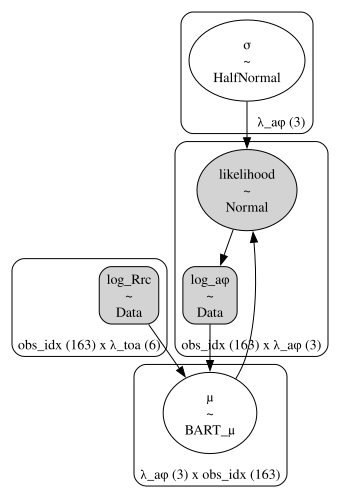

In [33]:
g

Note the arrow from the observed variable $log\_aφ$ to the BART mean (μ) in the model graph. This isn’t part of the generative model.This arrow reflects instead how PyMC builds the computational graph for inference. Internally, the observed data is used to compute residuals and update the trees during sampling, so PyMC shows a dependency that supports posterior updates but doesn’t imply that the BART prior is conditioned on the observed outcome.

In [34]:
with m_aph:
    idata_aph = pm.sample_prior_predictive()

Sampling: [likelihood, μ, σ]


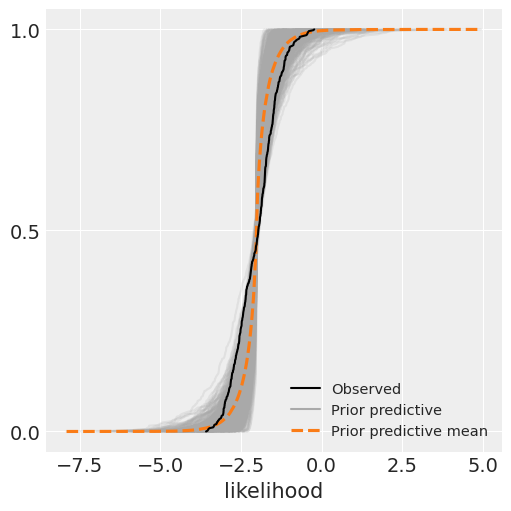

In [35]:
f, ax = pp.subplots(figsize=(5, 5))
ax= az.plot_ppc(idata_aph, group='prior', observed=True, kind='cumulative', ax=ax, colors=['darkgray', 'k', 'C1'])

Priors appear reasonable on account of the simulated output.

In [36]:
with m_aph:
    idata_aph.extend(pm.sample(draws=2000, chains=4, target_accept=0.95))

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


#### Sampling diagnostics

There are some warnings about convergence between independent sampling runs. If these are minors, the model is still likely to be OK. The main thing is to make sure that not too many values are beyond a Gelman-Rubin statistic ($\hat{R}$) of 1.01, particularly that we don't get any warnings about Effective Sample Size (ESS).

In [37]:
az.summary(idata_aph).r_hat.value_counts(normalize=True).round(2)

r_hat
1.01    0.66
1.00    0.24
1.02    0.10
1.03    0.01
Name: proportion, dtype: float64

Text(0.5, 0, '$\\hat{R}$')

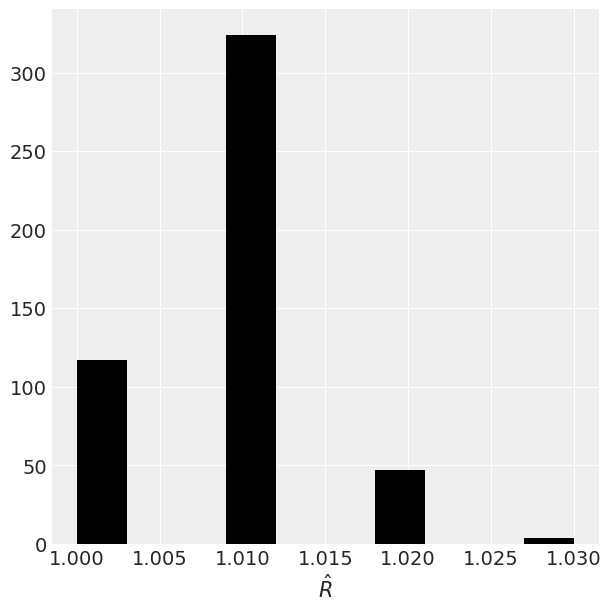

In [38]:
f, ax = pp.subplots(figsize=(6, 6))
az.summary(idata_aph, kind='diagnostics').r_hat.hist(ax=ax, color='k')
ax.set_xlabel(r'$\hat{R}$')

More than 95% of the samples are under 1.01, and the remainder is 1.02 or 1.03 anyway. This is acceptable. Next is to assess ESS, for both posterior region corresponding to  bulk and tail.

Text(0.5, 0, '$ESS_{tail}$')

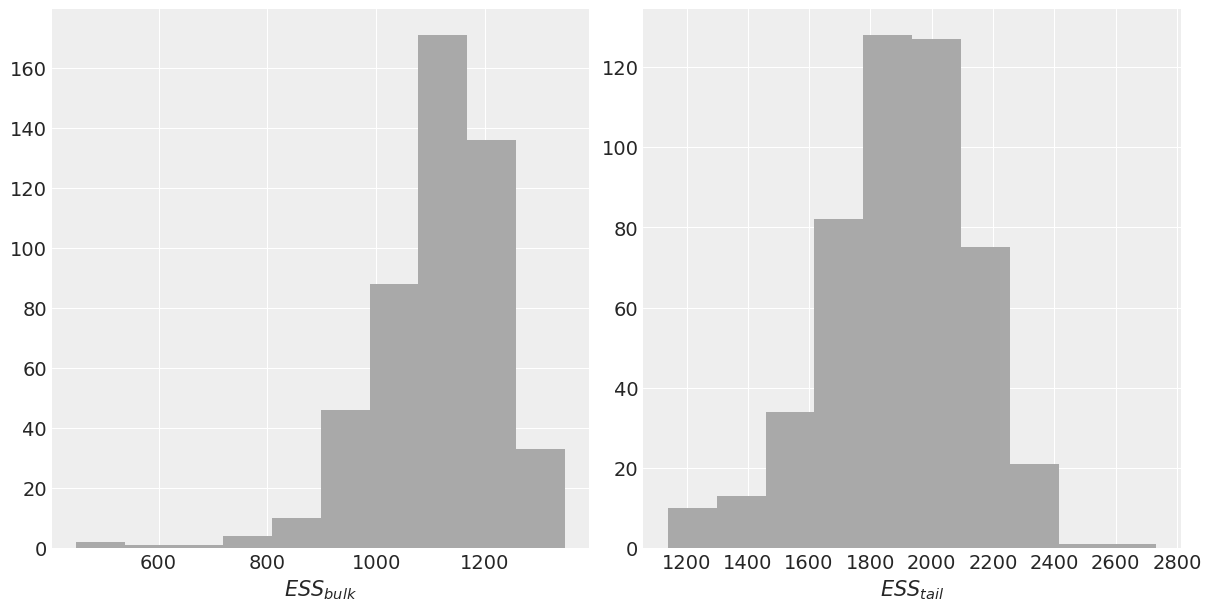

In [39]:
f, axs = pp.subplots(ncols=2, figsize=(12, 6))
az.summary(idata_aph, kind='diagnostics').ess_bulk.hist(ax=axs[0], color='darkgray')
az.summary(idata_aph, kind='diagnostics').ess_tail.hist(ax=axs[1], color='darkgray')
axs[0].set_xlabel(r'$ESS_{bulk}$')
axs[1].set_xlabel(r'$ESS_{tail}$')

Most of bulk and tail ESS are in the thousands of samples. This suggest good sampling.

Another diagnostic is the Energy plot. This applies to Hamiltonian Monte Carlo (HMC) samplers like the No U-Turn Sampler (NUTS), responsible for sampling continuous regions of the posteriorin, which in this case applies to the variance of the likelihood. Indeed the BART component is not continuous. Thus the mean of the likelihood (μ) is determined by the BART posterior, which is sampled using PG-BART (Particle Gibbs for BART). PG-BART is not a gradient-based method — it does not involve leapfrog integration, energy functions, or momentum resampling. Instead, PG-BART operates on discrete tree structures, which are non-differentiable. In particular PG-BART:
* Uses particle filtering + Gibbs sampling to explore the space of trees.
* Resamples trees based on their fit to the data, without needing any gradients.


The Energy plot for HMC helps assess how efficiently the sampler is exploring the posterior distribution. This plot helps assess how efficiently the sampler is exploring the posterior distribution. It shows two key distributions:

* Marginal Energy: The distribution of the Hamiltonian energy values across all samples. This is essentially a measure of the total "energy" (potential + kinetic) of the system at each sample.
* Energy Transition: The distribution of differences in energy between successive samples (i.e., energy jumps). Ideally, the transitions should be smooth and not show large jumps.

These matter because efficient HMC sampling assumes the energy landscape is smooth and traversable. Large or erratic energy transitions may indicate problems such as:

* Poor geometry (e.g., highly curved posteriors)
* Bad parameter scaling or priors
* Sampling stuck in narrow funnels or high-curvature areas


$⇒$ What BFMI Means:

BFMI = Bayesian Fraction of Missing Information

It quantifies how well the momentum resampling step in HMC is helping explore the energy landscape:
$$BFMI=\frac{Var(marginal energy)}{Var(energy transition)}$$
​

A low BFMI means the sampler isn't drawing enough momentum to explore distant parts of the posterior, which can result in biased samples or poor mixing.

$⇒$ What is a Good BFMI Value?

* BFMI ≥ 0.3 is generally considered acceptable.
* BFMI < 0.2 is a red flag indicating poor exploration and possible divergences.
* Ideally, values closer to 1 are better — indicating momentum is appropriately scaled to traverse the typical set efficiently.

$⇒$ How to Use the Plot:

* Compare the marginal energy and energy transition distributions. If they differ sharply, or if BFMI is low, your sampler may be inefficient.
* In ArviZ, low BFMI is often reported with a warning. There may also be differences in the plot (e.g., the energy transition distribution is narrow relative to the marginal energy).

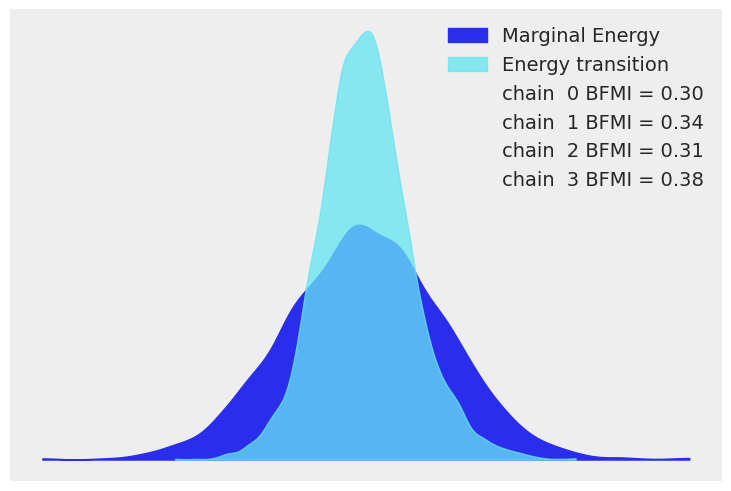

In [40]:
az.plot_energy(idata_aph)
f = pp.gcf()
f.savefig(image_save_path / 'model_1_energy_plot.png', dpi=300)
f.savefig(image_save_path / 'model_1_energy_plot.pdf', dpi=300)

Based on the above, the energy plot is mmarginal but still acceptable. Next is to check how well the sampling went. In particular see if the chains look like fuzzy caterpillar. Much of Bayesian model diagnostics rely on visual inspection.

Now we check convergence diagnostics for the BART portion of the model

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/ecdfplot.py:298: BehaviourChangeWarning: In future versions, if `eval_points` is not provided, then the ECDF will be evaluated at the unique values of the sample. To keep the current behavior, provide `eval_points` explicitly.
  warnings.warn(


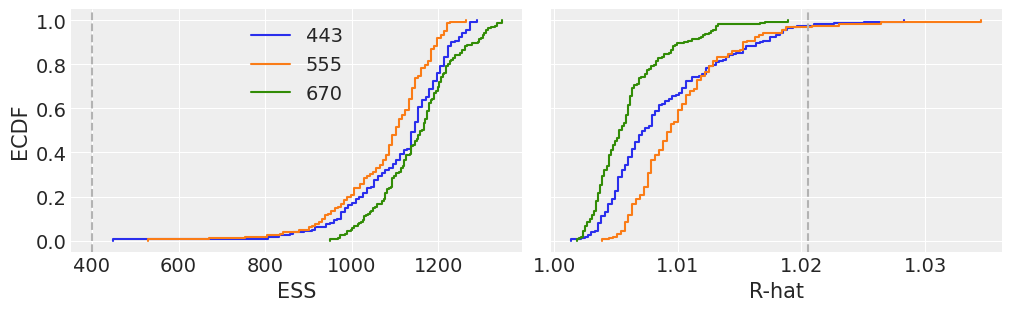

In [41]:
axs = pmb.plot_convergence(idata=idata_aph, var_name='μ', )
axs[0].set_ylabel('ECDF')
legend_handles = [
    Line2D([0], [0], color='C0', label='443'),
    Line2D([0], [0], color='C1',label='555'),
    Line2D([0], [0], color='C2',label='670')
]
axs[0].legend(handles=legend_handles)
f = pp.gcf()
f.savefig(image_save_path/'model1_bart_convergence.png', dpi=300)
f.savefig(image_save_path/'model1_bart_convergence.pdf', dpi=300)

The desired outcome is for the ESS plot lines (left) to be greater than the limit suggested by the dashed line, and less than the dashed line for the $\hat{R}$ plot (right). This satisfied for ESS and mostly satsified for the $\hat{R}$.

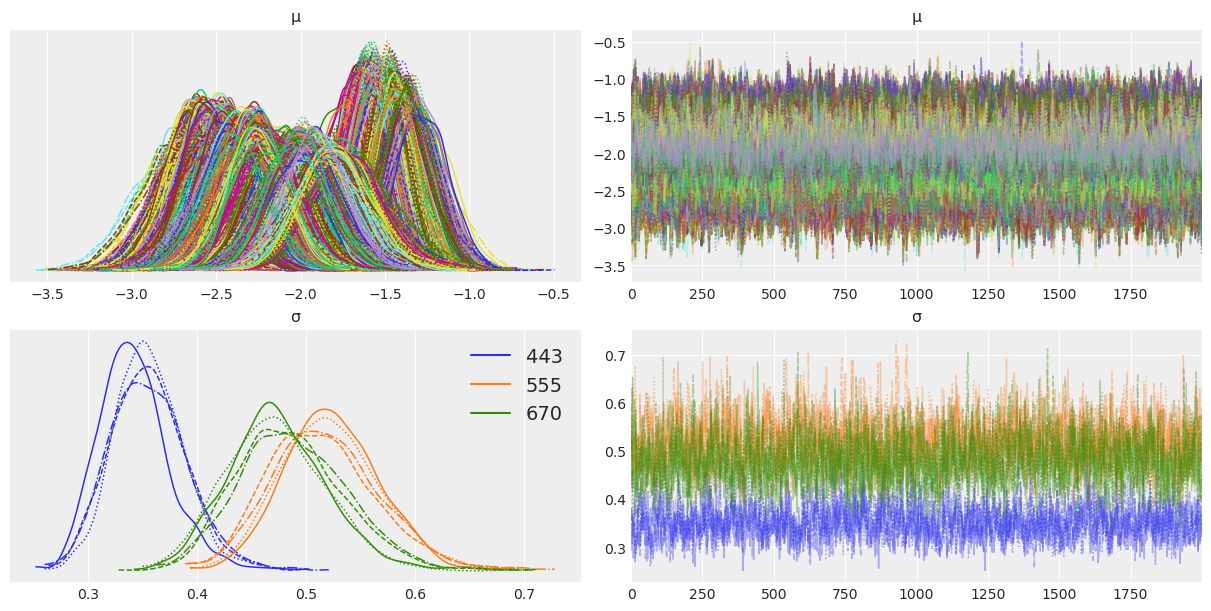

In [42]:
f, axs = pp.subplots(2, 2, figsize=(12, 6))
az.plot_trace(idata_aph, axes=axs)
axs.ravel()[2].legend(handles=legend_handles)
f = pp.gcf()
f.savefig(image_save_path / 'm1_bart_trace.png', dpi=300)
f.savefig(image_save_path / 'm1_bart_trace.pdf', dpi=300)

Traces do not show obvious patterns or trends, suggesting well-mixed chains, indicative of adquate sampling. This concludes the section on model fitting diagnostics.


## Model Post-Fit Analysis

Having verified that PyMC did an good job sampling the posterior I analyze how well the model has learned. But first, a few helper functions defined below:

In [43]:
def plot_regression_hdi(idata):
    y_hat_94 = az.hdi(
        idata.posterior_predictive.likelihood).likelihood.to_numpy()
    y_hat_63 = az.hdi(
        idata.posterior_predictive.likelihood, hdi_prob=0.63).likelihood.to_numpy()
    y = idata.observed_data.likelihood.to_numpy()
    x = np.arange(y.size)
    idx = np.argsort(y)

    f, ax = pp.subplots(figsize=(12, 8))
    ax.fill_between(x=x, y1 = y_hat_94[idx, 0], y2=y_hat_94[idx, 1], color='black', label='94% HDI')
    ax.fill_between(x=x, y1=y_hat_63[idx, 0], y2=y_hat_63[idx, 1 ], color='darkgray', label='63% HDI')
    ax.scatter(x, y[idx], s=30, color='red', label='observed')
    ax.legend()
    ax.set_xlabel('observation #')
    ax.set_ylabel(r'$a_φ(443)$')
    return f, ax

In [44]:
def plot_3_way_ppc(idata, colors=['darkgray', 'k', 'C1'], kind='kde', include_all=True):
    if include_all:
        f, axs = pp.subplots(ncols=2, nrows=2, figsize=(8, 8), sharex=True, sharey=True)
        ax = axs.ravel()[-1]
        ax.set_title('All targets')
        az.plot_ppc(idata, ax=axs.ravel()[-1], colors=colors, kind=kind)
        ax.set_xlabel(f'log(aφ)')
    else:
        f, axs= pp.subplots(ncols=3, figsize=(13, 4), sharex=True, sharey=True)
    bands = ['443', '555', '670']
    for i, (ax, band) in enumerate(zip(axs.ravel(), bands)):
        az.plot_ppc(
            idata, coords={'λ_aφ': band }, ax=ax, colors=colors, kind=kind, legend=False)
        ax.set_title(f'λ = {band}')
        if i==2:
            ax.set_xlabel(f'log(aφ)')
    return f, ax

Next is to simulate $log(aΦ)$ from the posterior; posterior predictive checks

In [45]:
with m_aph:
    idata_aph.extend(pm.sample_posterior_predictive(idata_aph))

Sampling: [likelihood]


Output()

Did the model learn: comparing prior and posterior predictive checks

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/1813936715.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'model1_prior_posterior_pc.png', dpi=300)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/1813936715.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'model1_prior_posterior_pc.pdf', dpi=300)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


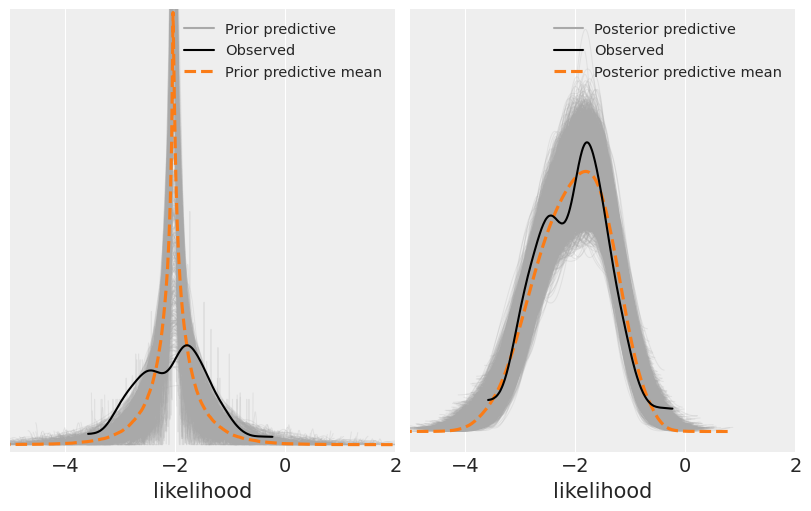

In [46]:
f, ax= pp.subplots(ncols=2, figsize=(8, 5), sharex=True)
az.plot_ppc(idata_aph, group='prior', observed=True, ax=ax[0], colors=['darkgray', 'k', 'C1'])
az.plot_ppc(idata_aph, ax=ax[1], colors=['darkgray', 'k', 'C1'])
ax[0].set_xlim(-5, 3)
ax[1].set_xlim(-5, 2)
y_lims = ax[1].get_ylim()
ax[0].set_ylim(y_lims[0], y_lims[1]* 3)
f.savefig(image_save_path / 'model1_prior_posterior_pc.png', dpi=300)
f.savefig(image_save_path / 'model1_prior_posterior_pc.pdf', dpi=300)

The simulated data is much closer to the observations. The uncertainty captures the skewed bimodal nature of the data. Note that the simulated data is monomodal because I gave the model a Gaussian likelihood. I don't feel comfortable proposing a more complex likelihood, as the bimodality could be an artifact of the data paucity. This can be updated later as more data comes and the need to change the likelihood becomes apparent. For now the posterior predictive checks (on the right), suggests the model approximates the data generation process quite well. Next, I examine the same posterior predictive checks for each of the 3 phytoplankton absorption (aφ) bands.

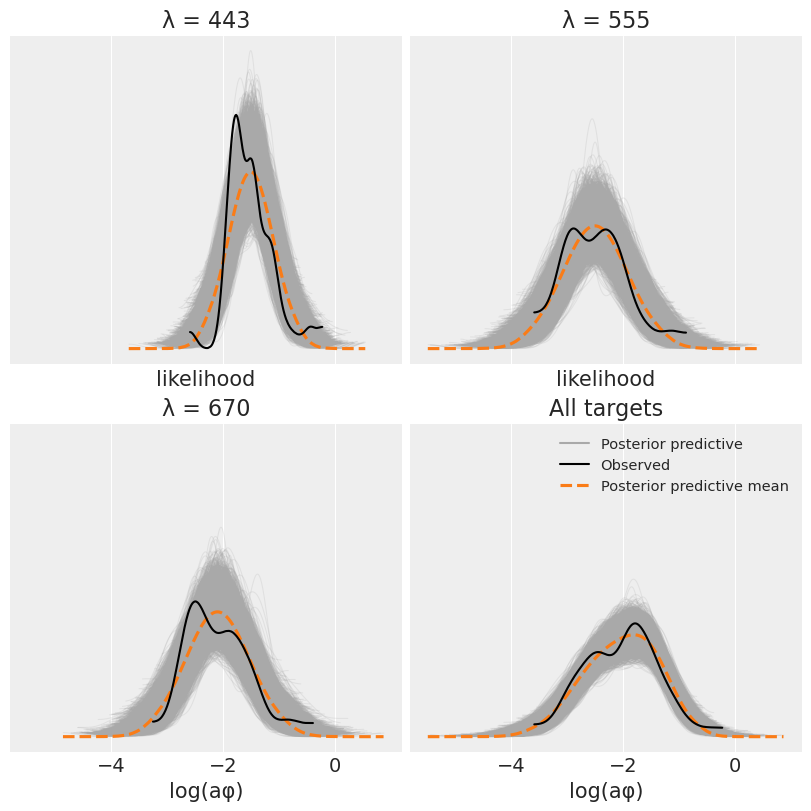

In [48]:
f, ax = plot_3_way_ppc(idata_aph, include_all=True)
f.savefig(image_save_path / 'm1_3_way_ppc.png', dpi=300)
f.savefig(image_save_path / 'm1_3_way_ppc.pdf', dpi=300)

Another useful view of the above is the empirical cumulative distribution function, below.

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/4078440884.py:2: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_3_way_ppc_cdf.png', dpi=300)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/4078440884.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_3_way_ppc_cdf.pdf', dpi=300)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


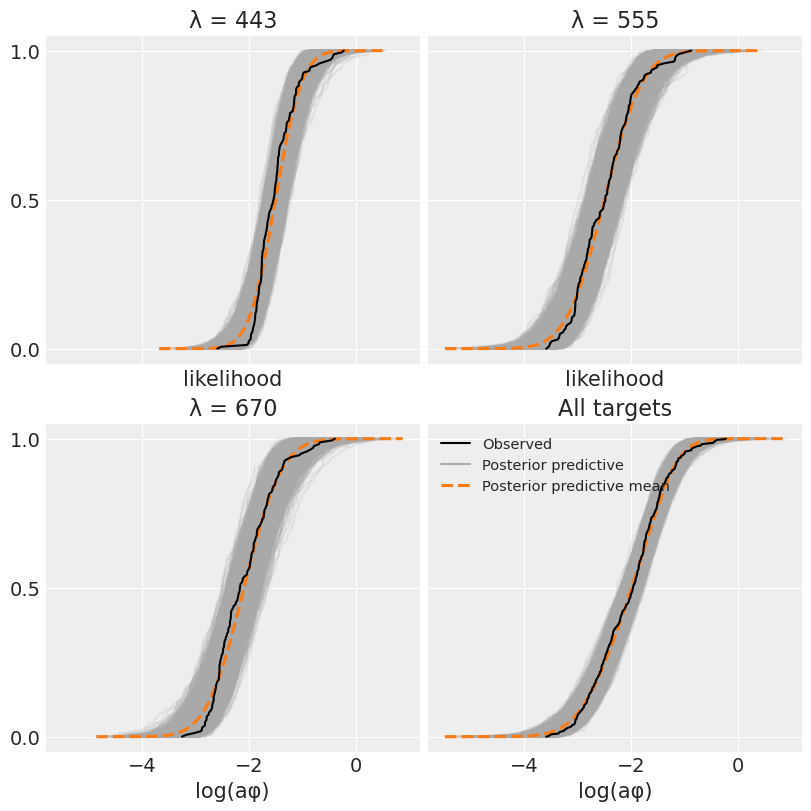

In [50]:
f, ax = plot_3_way_ppc(idata_aph, kind='cumulative', include_all=True)
f.savefig(image_save_path / 'm1_3_way_ppc_cdf.png', dpi=300)
f.savefig(image_save_path / 'm1_3_way_ppc_cdf.pdf', dpi=300)

#### A quick look at band-specific variance
This hows that aφ(555), and aφ(670) are similarly dispersed, and similarly uncertain. The variance of aφ(443) is smaller and less uncertain

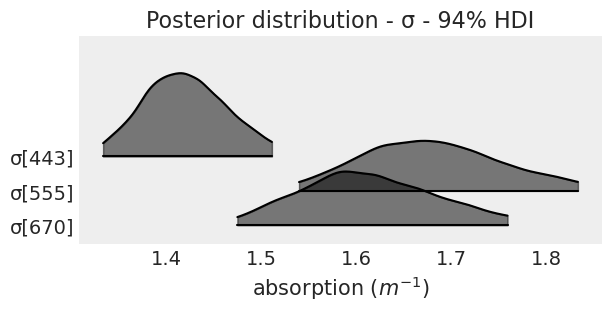

In [58]:
f, ax = pp.subplots(figsize=(6, 3))
az.plot_forest(idata_aph, kind='ridgeplot', ridgeplot_alpha=0.5, var_names='σ', ax=ax, combined=True, transform=np.exp, colors='k' )
ax.set_yticklabels(['σ[670]', 'σ[555]', 'σ[443]']);
ax.set_title('Posterior distribution - σ - 94% HDI')
ax.set_xlabel(r'absorption ($m^{-1}$)')
f.savefig(image_save_path / 'm1_σ_forest.png', dpi=300)
f.savefig(image_save_path / 'm1_σ_forest.pdf', dpi=300)

The plot above (rescaled to linear units of absorption) shows significant differences between 443 and the other two bands. 555 and 670 are on the other hand essentially indistinguishable from one another.


### Partial Conditional Dependence


In [ ]:
mu_ = m_aph.μ

In [59]:
idata_aph.posterior_predictive

<xarray.Dataset> Size: 31MB
Dimensions:     (chain: 4, draw: 2000, obs_idx: 163, λ_aφ: 3)
Coordinates:
  * chain       (chain) int64 32B 0 1 2 3
  * draw        (draw) int64 16kB 0 1 2 3 4 5 ... 1994 1995 1996 1997 1998 1999
  * obs_idx     (obs_idx) int64 1kB 2 3 26 31 32 33 ... 487 488 489 490 492 494
  * λ_aφ        (λ_aφ) <U3 36B '443' '555' '670'
Data variables:
    likelihood  (chain, draw, obs_idx, λ_aφ) float64 31MB -1.26 ... -0.8191
Attributes:
    created_at:                 2025-06-26T14:15:11.208272+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.20.1

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/2362500510.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


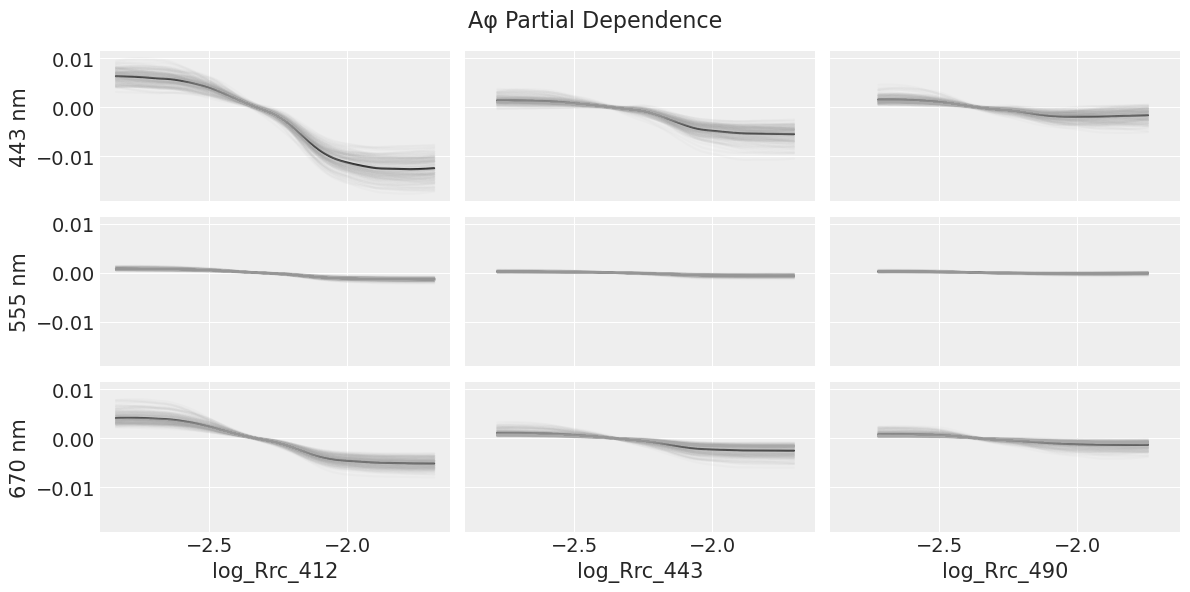

In [102]:
func=lambda x: 10**x
f, axs = pp.subplots(nrows=3, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
axs_0 = axs[:, 0]
axs_1 = axs[:, 1]
axs_2 = axs[:, 2]
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[0], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_0, func=func)
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[1], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_1, func=func)
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[2], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_2, func=func)
for i, (ax0, ax1, ax2, l) in enumerate(zip(axs_0, axs_1, axs_2, coords['λ_aφ'])):
    ax0.set_ylabel(f'{l} nm')  # Get the current figure
    if i<2: 
        ax0.set_xlabel('')
        ax1.set_xlabel('')
        ax2.set_xlabel('')

f.texts.clear()
f.suptitle("Aφ Partial Dependence", fontsize=16)
f.tight_layout()


In [ ]:
f, axs = pp.subplots(nrows=3, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
axs_0 = axs[:, 0]
axs_1 = axs[:, 1]
axs_2 = axs[:, 2]
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[3], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_0, func=func)
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[4], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_1, func=func)
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[5], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_2, func=func)
for i, (ax0, ax1, ax2, l) in enumerate(zip(axs_0, axs_1, axs_2, coords['λ_aφ'])):
    ax0.set_ylabel(f'{l} nm')  # Get the current figure
    if i<2: 
        ax0.set_xlabel('')
        ax1.set_xlabel('')
        ax2.set_xlabel('')

f.texts.clear()
f.suptitle("Aφ Partial Dependence", fontsize=16)
f.tight_layout()

### Individual Conditional Expectation

In [ ]:
m_aph.likelihood

μ ~ BART(<shared>, <shared>, 10, 0.9, 4)

In [ ]:
m_aph.μ.

### Variable Importance

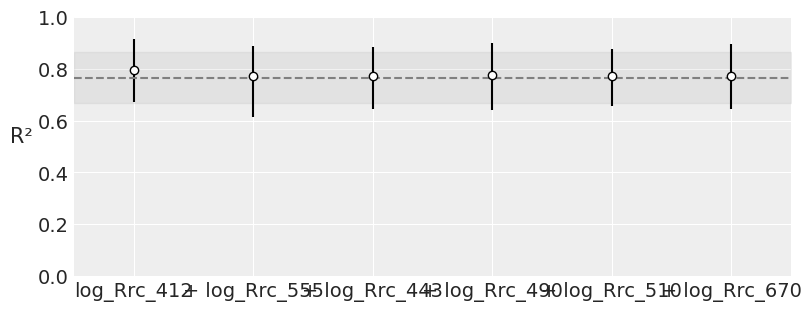

In [ ]:
vi_results = pmb.compute_variable_importance(idata_aph, m_aph.μ, X, samples=100)
pmb.plot_variable_importance(vi_results,);

In [94]:
vi_results

{'indices': array([0, 4, 1, 2, 3, 5]),
 'labels': array(['log_Rrc_412', '+ log_Rrc_555', '+ log_Rrc_443', '+ log_Rrc_490',
        '+ log_Rrc_510', '+ log_Rrc_670'], dtype='<U13'),
 'r2_mean': array([0.80082504, 0.77755737, 0.78460533, 0.79151884, 0.76180749,
        0.76265737]),
 'r2_hdi': array([[0.71204691, 0.88536545],
        [0.62323543, 0.88453819],
        [0.68995792, 0.89521005],
        [0.68983922, 0.9004427 ],
        [0.66066031, 0.89352867],
        [0.64349182, 0.86288054]]),
 'preds': array([[[[-1.37525791, -2.46186146, -1.92217527],
          [-1.53642557, -2.47356605, -1.90810185],
          [-1.61539589, -2.67531042, -2.46436585],
          ...,
          [-1.37525791, -2.46186146, -1.92217527],
          [-1.53642557, -2.47356605, -1.90810185],
          [-1.37525791, -2.46186146, -1.92217527]],
 
         [[-1.46849322, -2.36071024, -2.08658608],
          [-1.48500175, -2.41541343, -2.07939363],
          [-1.40875468, -2.5366874 , -2.27370053],
          ...,
 

## Model Generalization